In [ ]:
!pip install category_encoders shap yellowbrick

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 2.3 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import warnings
import shap
import category_encoders as ce

from scipy import stats
from scipy.stats import skew, boxcox
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

from sklearn.preprocessing import PolynomialFeatures, StandardScaler, MinMaxScaler, RobustScaler, LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, cross_validate
from sklearn.linear_model import LinearRegression, Ridge, RidgeCV, Lasso, LassoCV, ElasticNet, ElasticNetCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from yellowbrick.regressor import ResidualsPlot, PredictionError
from category_encoders import TargetEncoder
from ipywidgets import interact

warnings.filterwarnings("ignore")

In [ ]:
# Forma 2)

# Reemplaza con el ID real de tu archivo en Drive
file_id = '1yDvY2aX570bRvDdI9OVgZsGraLFobrNS'
url = f'https://drive.google.com/uc?export=download&id={file_id}'

# Cargar el dataset
df = pd.read_csv(url)
df


#https://drive.google.com/file/d/1yDvY2aX570bRvDdI9OVgZsGraLFobrNS/view?usp=sharing

,student_id,age,gender,gaming_hours,study_hours,sleep_hours,attendance,gaming_genre,social_activity,device_usage,reaction_time_ms,addiction_score,stress_level,grades
0,1,22,Male,7.23,8.78,6.96,91.44,FPS,3.25,9.36,235.84,14.69,Low,86.459555
1,2,19,Male,0.07,8.72,7.63,63.63,Casual,1.02,3.21,328.71,2.47,Medium,98.230000
2,3,23,Female,1.73,9.56,4.40,83.26,Casual,3.46,5.56,313.61,4.73,High,90.560000
3,4,20,Female,6.62,1.68,7.83,75.04,RPG,1.46,11.78,241.84,14.54,Low,32.670000
4,5,22,Female,5.36,5.83,5.55,65.57,FPS,1.01,8.23,249.31,12.48,Low,58.710000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7995,7996,24,Male,6.33,5.09,4.83,63.74,FPS,4.11,9.96,231.33,11.14,Low,35.110000
7996,7997,22,Female,5.77,6.09,6.23,84.37,FPS,3.42,11.19,254.13,10.66,Low,60.800000
7997,7998,20,Male,2.87,8.51,8.62,67.30,FPS,2.36,6.40,305.00,6.42,Medium,90.280000
7998,7999,22,Female,0.98,2.99,7.29,61.13,FPS,2.02,4.57,325.36,2.14,Medium,56.330000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   student_id        8000 non-null   int64  
 1   age               8000 non-null   int64  
 2   gender            8000 non-null   object 
 3   gaming_hours      8000 non-null   float64
 4   study_hours       8000 non-null   float64
 5   sleep_hours       8000 non-null   float64
 6   attendance        8000 non-null   float64
 7   gaming_genre      8000 non-null   object 
 8   social_activity   8000 non-null   float64
 9   device_usage      8000 non-null   float64
 10  reaction_time_ms  8000 non-null   float64
 11  addiction_score   8000 non-null   float64
 12  stress_level      8000 non-null   object 
 13  grades            8000 non-null   float64
dtypes: float64(9), int64(2), object(3)
memory usage: 875.1+ KB


In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
student_id,8000.0,4000.500000,2309.545410,1.00,2000.750000,4000.500,6000.250000,8000.000000
age,8000.0,19.983625,2.587072,16.00,18.000000,20.000,22.000000,24.000000
gaming_hours,8000.0,4.085773,2.308801,0.00,2.130000,4.130,6.060000,8.000000
study_hours,8000.0,5.460581,2.575787,1.00,3.240000,5.460,7.660000,10.000000
sleep_hours,8000.0,6.493453,1.442656,4.00,5.240000,6.505,7.730000,9.000000
attendance,8000.0,79.886525,11.580419,60.00,69.780000,79.695,90.100000,100.000000
social_activity,8000.0,2.507790,1.441128,0.00,1.287500,2.500,3.760000,5.000000
device_usage,8000.0,7.586315,2.710035,1.10,5.560000,7.610,9.600000,13.950000
reaction_time_ms,8000.0,271.105839,29.440675,183.26,247.160000,270.475,294.690000,347.870000
addiction_score,8000.0,9.908492,5.035837,-4.51,5.920000,10.005,13.860000,23.160000


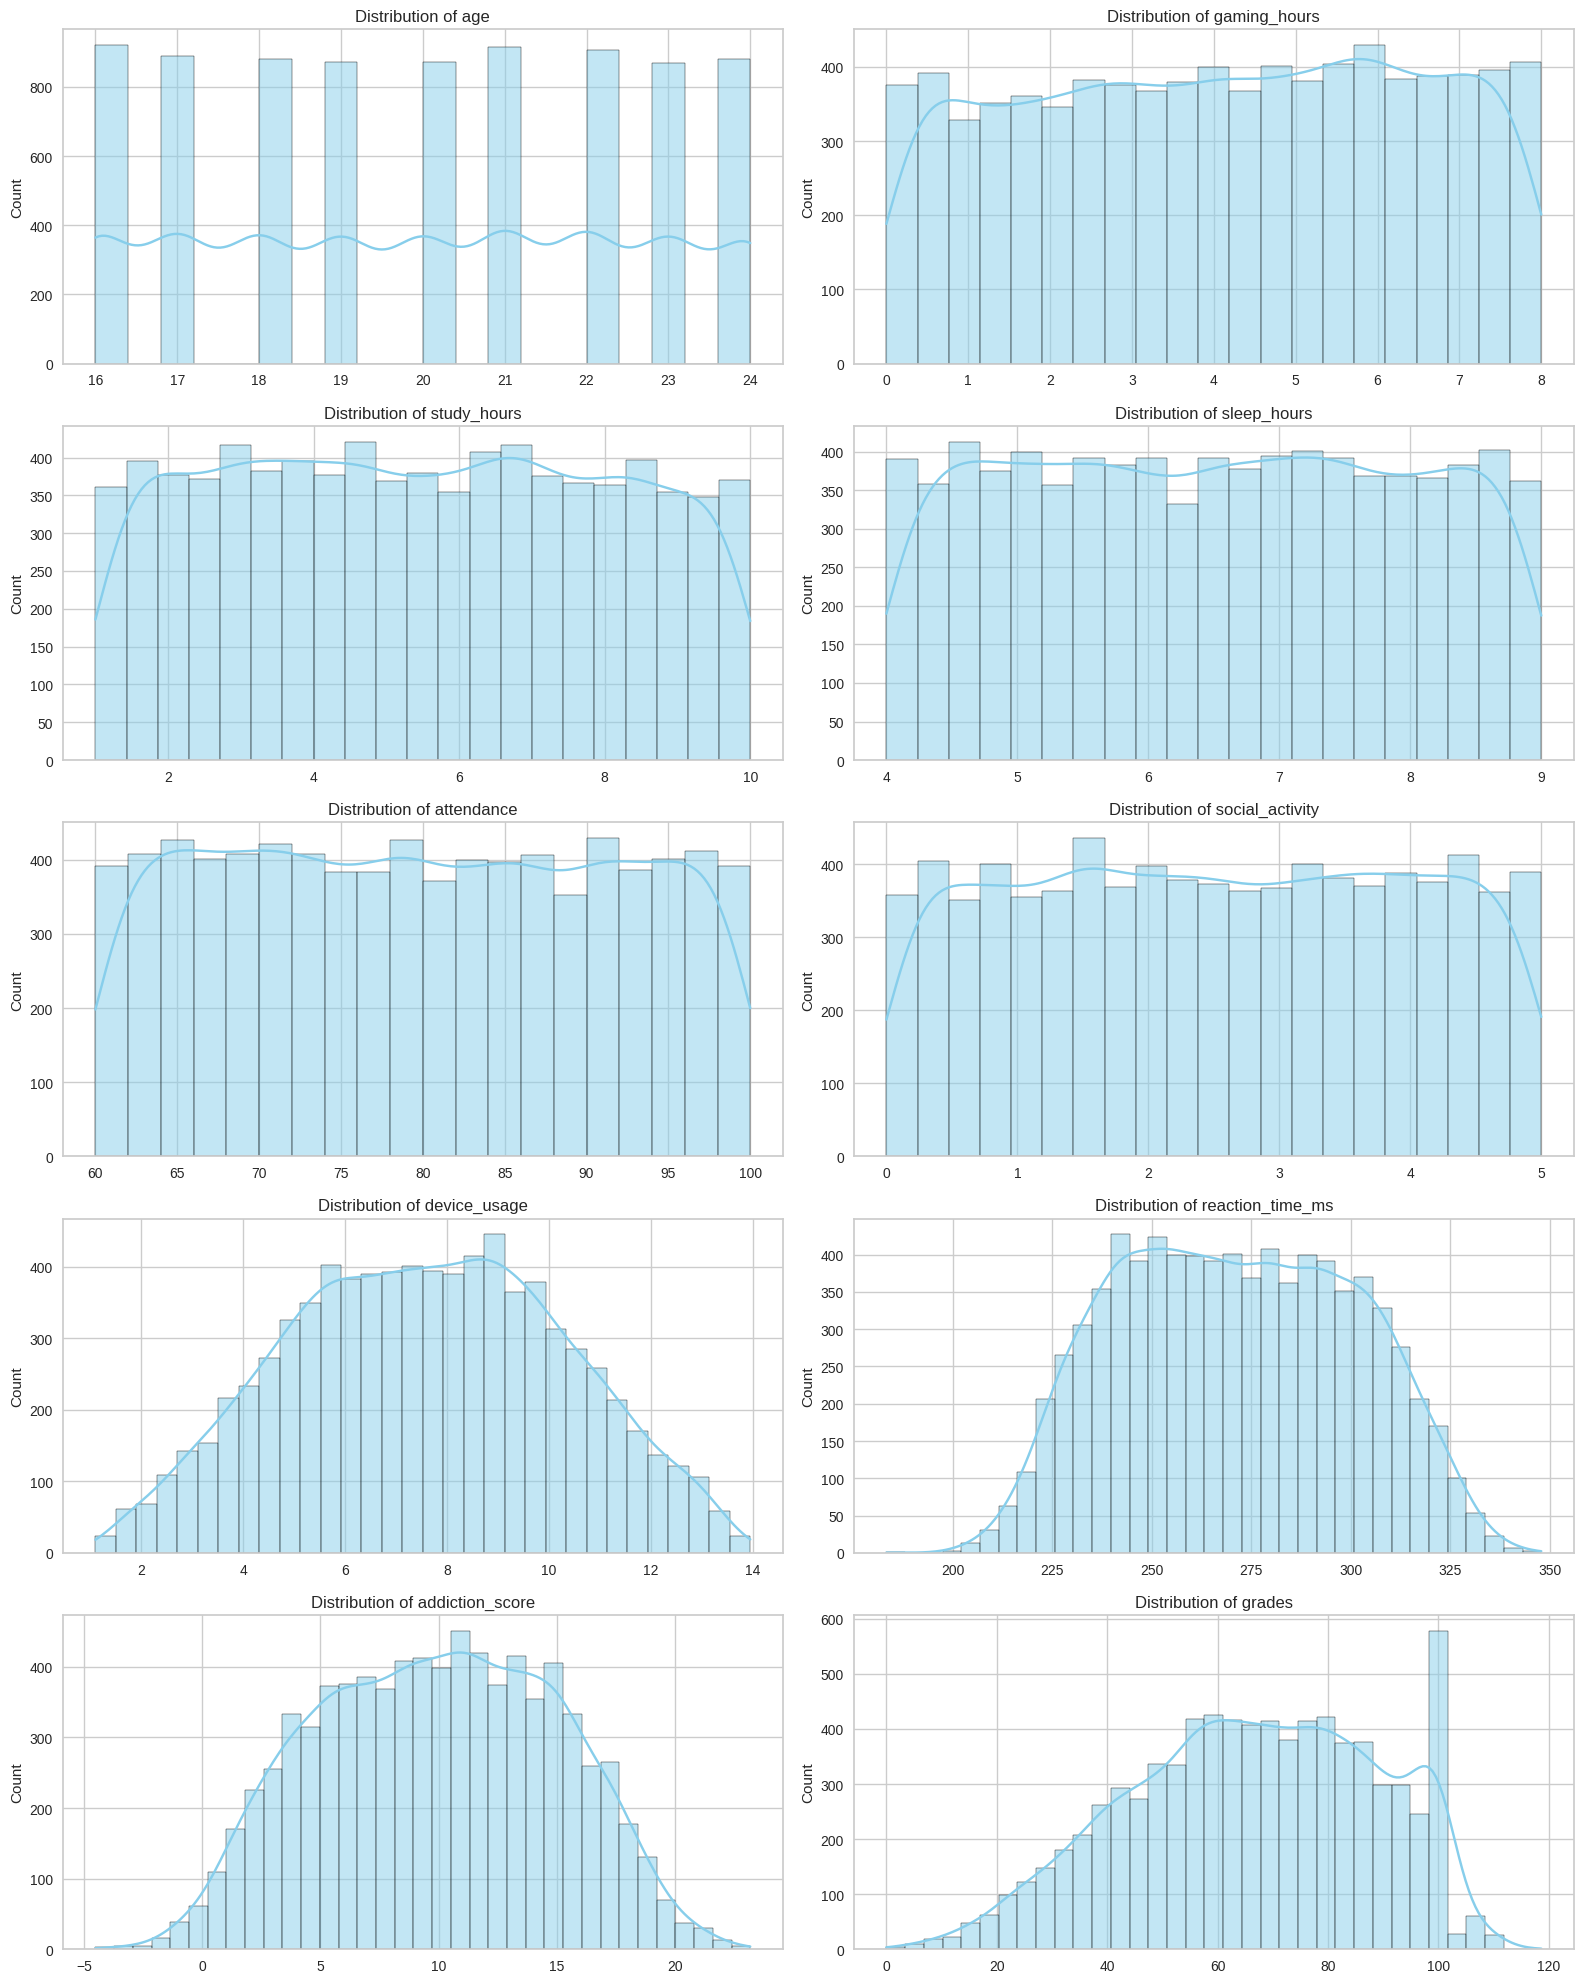

In [ ]:
# Ensure data is loaded
file_id = '1yDvY2aX570bRvDdI9OVgZsGraLFobrNS'
url = f'https://drive.google.com/uc?export=download&id={file_id}'
df = pd.read_csv(url)

# Identify numerical columns excluding the ID
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
if 'student_id' in numerical_cols:
    numerical_cols.remove('student_id')

# Configure plot grid
n_cols = 2
n_rows = (len(numerical_cols) + 1) // n_cols

plt.figure(figsize=(16, 4 * n_rows))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.histplot(df[col], kde=True, color='skyblue')
    plt.title(f'Distribution of {col}')
    plt.xlabel('')

plt.tight_layout()
plt.show()

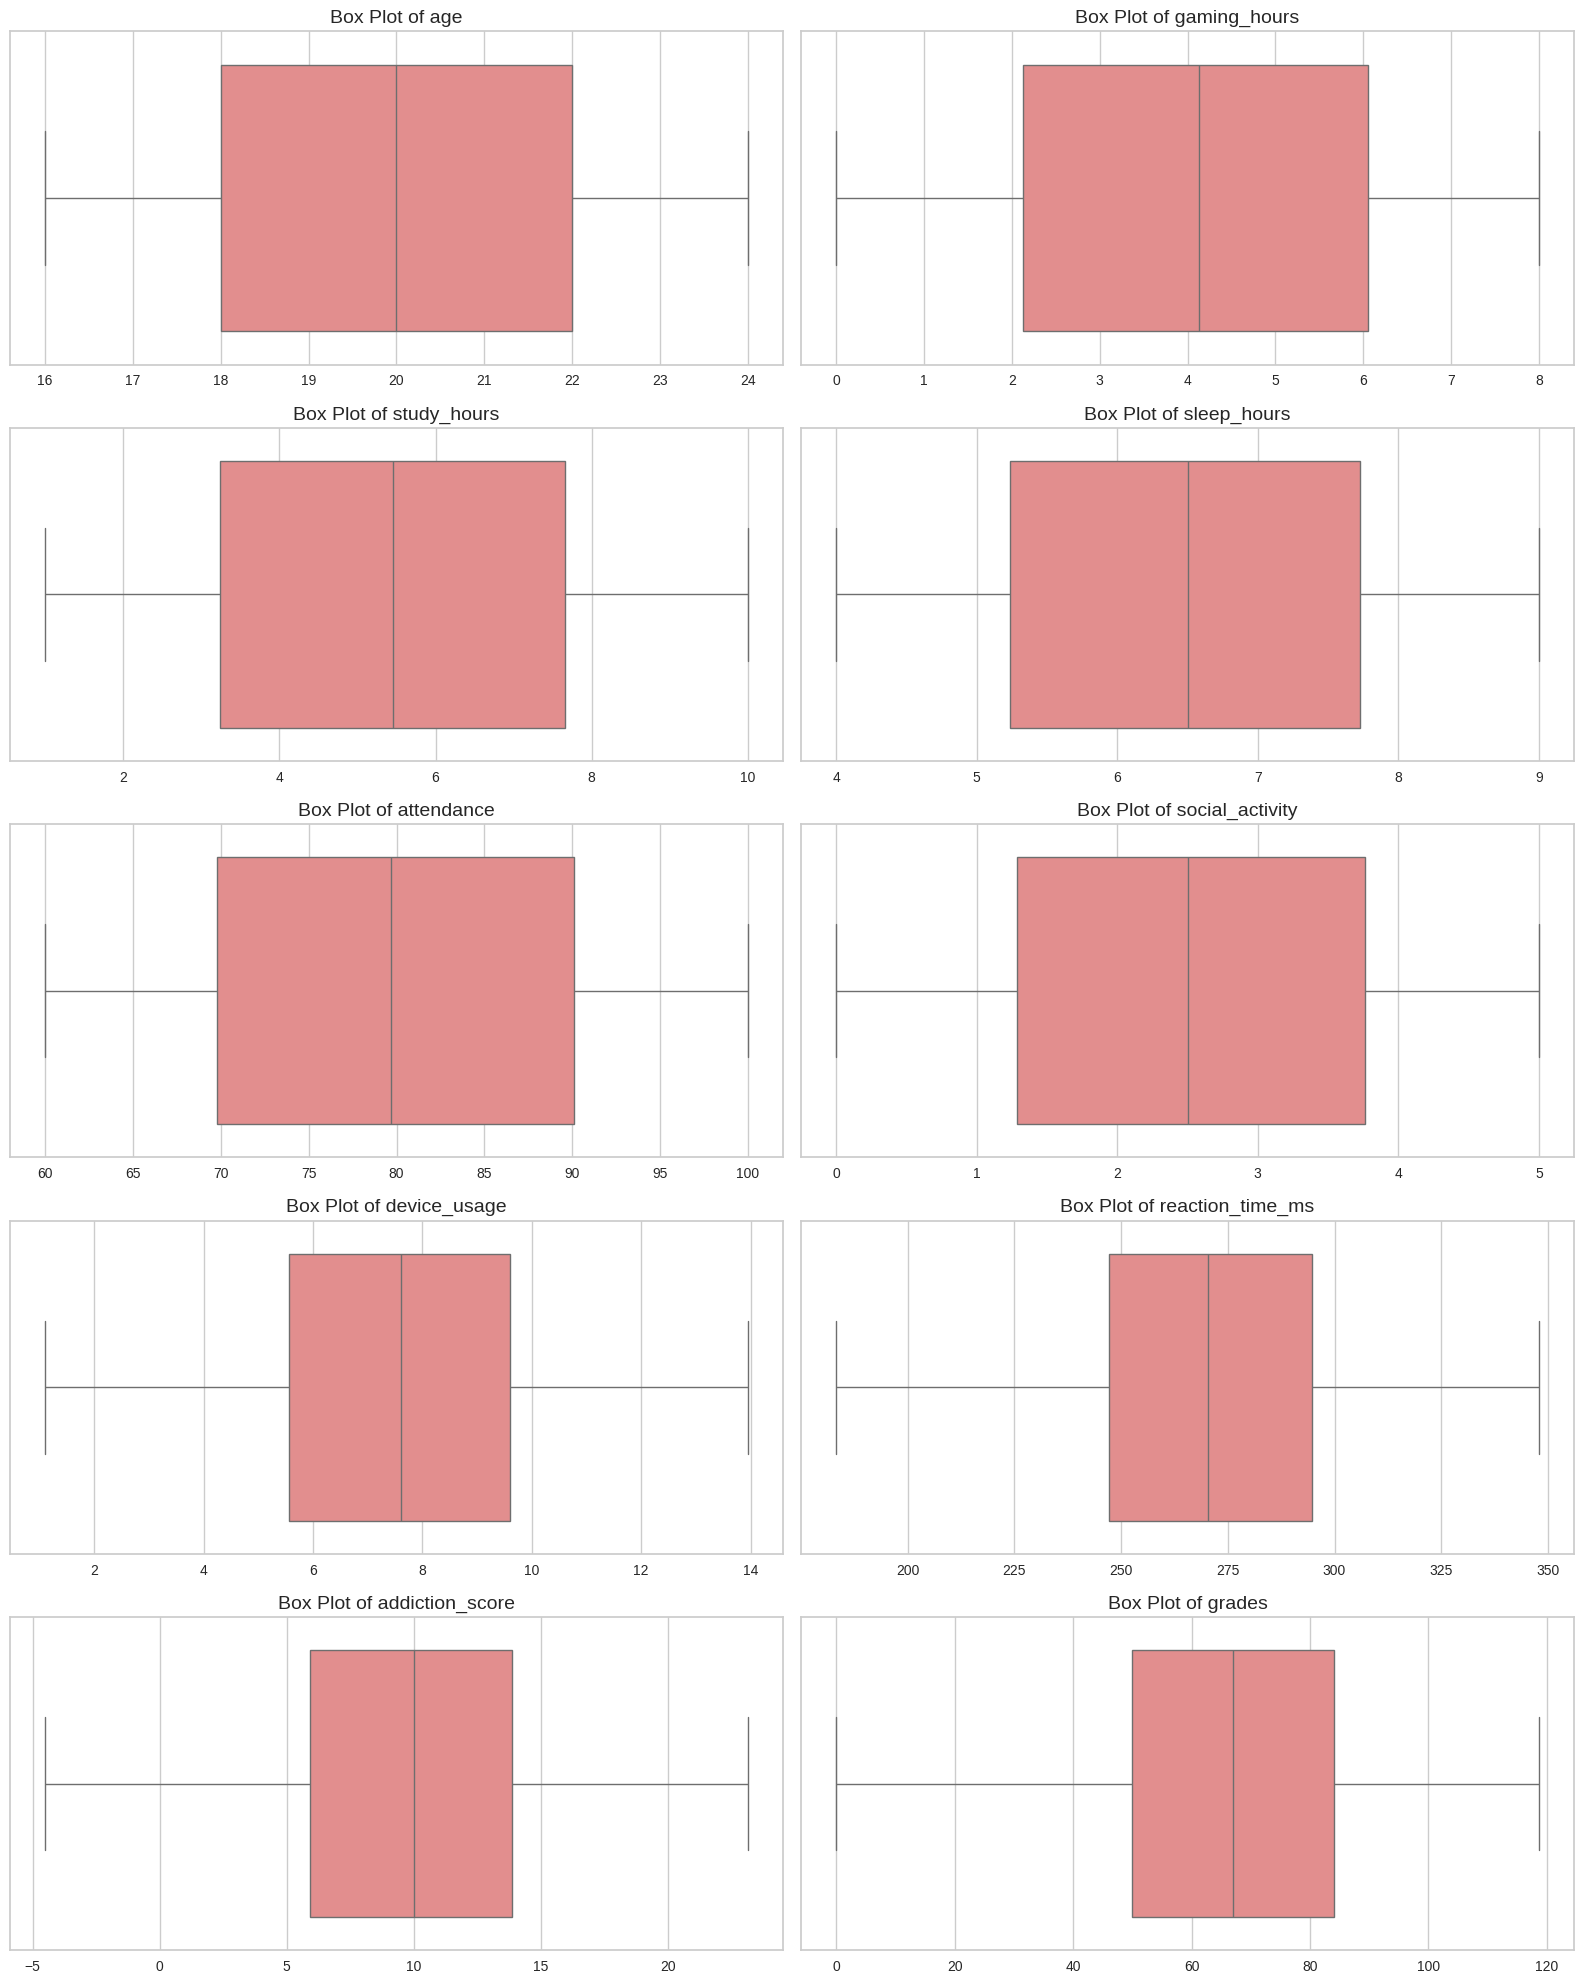

In [ ]:
# Identify numerical columns excluding the ID
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
if 'student_id' in numerical_cols:
    numerical_cols.remove('student_id')

# Configure plot grid for boxplots
n_cols = 2
n_rows = (len(numerical_cols) + 1) // n_cols

plt.figure(figsize=(16, 4 * n_rows))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(x=df[col], color='lightcoral')
    plt.title(f'Box Plot of {col}', fontsize=14)
    plt.xlabel('')

plt.tight_layout()
plt.show()

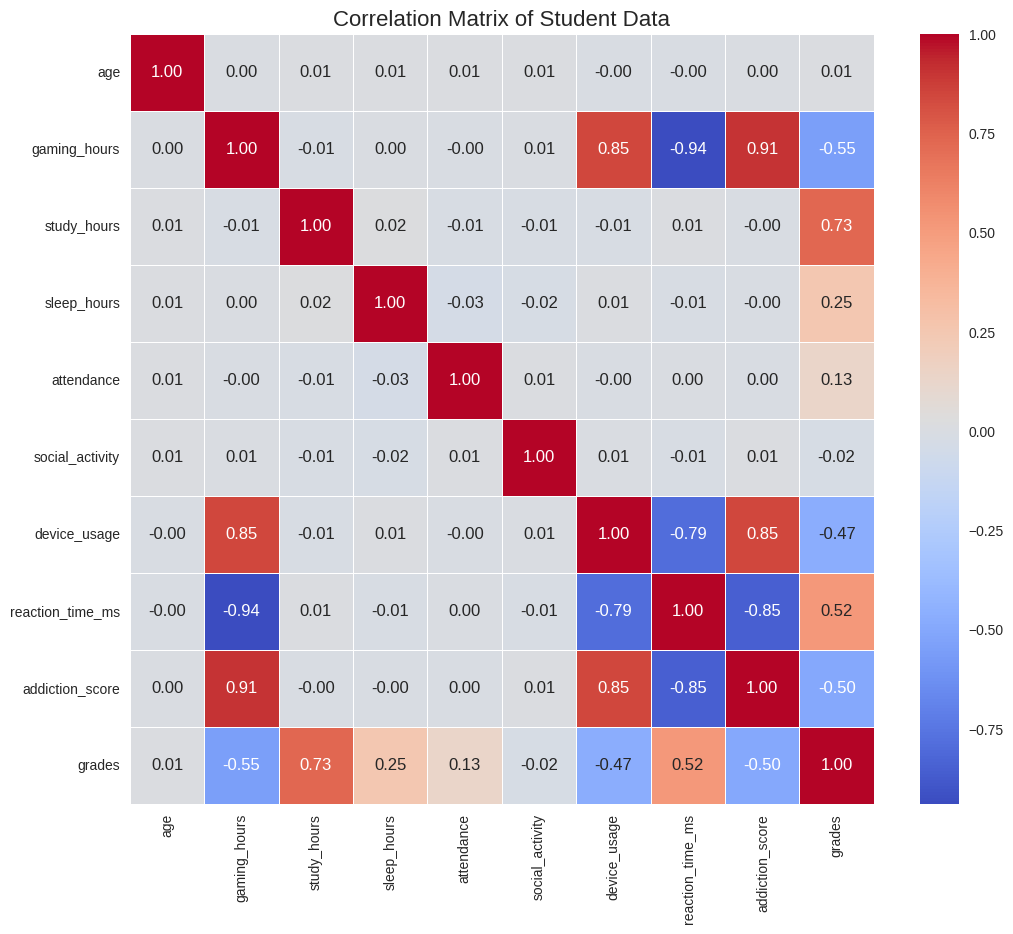

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate correlation matrix only for numerical columns
corr_matrix = df.select_dtypes(include=['float64', 'int64']).drop(columns=['student_id'], errors='ignore').corr()

# Set up the matplotlib figure
plt.figure(figsize=(12, 10))

# Create a heatmap
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)

plt.title('Correlation Matrix of Student Data', fontsize=16)
plt.show()

### 1. Label Encoding
Label encoding assigns a unique integer to each category. It is useful for ordinal data (like `stress_level`).

In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Asegurar que los datos están cargados en esta sesión
file_id = '1yDvY2aX570bRvDdI9OVgZsGraLFobrNS'
url = f'https://drive.google.com/uc?export=download&id={file_id}'
df = pd.read_csv(url)

df_label = df.copy()
le = LabelEncoder()

cat_cols = ['gender', 'gaming_genre', 'stress_level']
for col in cat_cols:
    df_label[col] = le.fit_transform(df_label[col].astype(str))

print("Label Encoded DataFrame (primeras 5 filas):")
display(df_label.head())

Label Encoded DataFrame (primeras 5 filas):


,student_id,age,gender,gaming_hours,study_hours,sleep_hours,attendance,gaming_genre,social_activity,device_usage,reaction_time_ms,addiction_score,stress_level,grades
0,1,22,1,7.23,8.78,6.96,91.44,1,3.25,9.36,235.84,14.69,1,86.459555
1,2,19,1,0.07,8.72,7.63,63.63,0,1.02,3.21,328.71,2.47,2,98.230000
2,3,23,0,1.73,9.56,4.40,83.26,0,3.46,5.56,313.61,4.73,0,90.560000
3,4,20,0,6.62,1.68,7.83,75.04,2,1.46,11.78,241.84,14.54,1,32.670000
4,5,22,0,5.36,5.83,5.55,65.57,1,1.01,8.23,249.31,12.48,1,58.710000


### 2. One-Hot Encoding
One-hot encoding creates binary columns for each category. This is ideal for nominal data (like `gender` and `gaming_genre`) where no order exists.

In [ ]:
import pandas as pd

# One-Hot Encoding
df_onehot = pd.get_dummies(df, columns=['gender', 'gaming_genre', 'stress_level'], drop_first=True)

print("One-Hot Encoded DataFrame (primeras 5 filas):")
display(df_onehot.head())

One-Hot Encoded DataFrame (primeras 5 filas):


,student_id,age,gaming_hours,study_hours,sleep_hours,attendance,social_activity,device_usage,reaction_time_ms,addiction_score,grades,gender_Male,gender_Other,gaming_genre_FPS,gaming_genre_RPG,stress_level_Low,stress_level_Medium
0,1,22,7.23,8.78,6.96,91.44,3.25,9.36,235.84,14.69,86.459555,True,False,True,False,True,False
1,2,19,0.07,8.72,7.63,63.63,1.02,3.21,328.71,2.47,98.230000,True,False,False,False,False,True
2,3,23,1.73,9.56,4.40,83.26,3.46,5.56,313.61,4.73,90.560000,False,False,False,False,False,False
3,4,20,6.62,1.68,7.83,75.04,1.46,11.78,241.84,14.54,32.670000,False,False,False,True,True,False
4,5,22,5.36,5.83,5.55,65.57,1.01,8.23,249.31,12.48,58.710000,False,False,True,False,True,False


### 3. Target Encoding
Target encoding replaces categories with the mean of the target variable (`grades`) for that category. It is powerful but requires caution to avoid overfitting.

In [ ]:
import pandas as pd
try:
    from category_encoders import TargetEncoder
except ImportError:
    !pip install -q category_encoders
    from category_encoders import TargetEncoder

df_target = df.copy()
te = TargetEncoder(cols=['gender', 'gaming_genre', 'stress_level'])

# Codificación usando 'grades' como objetivo
df_target_encoded = te.fit_transform(df_target, df_target['grades'])

print("Target Encoded DataFrame (primeras 5 filas):")
display(df_target_encoded.head())

Target Encoded DataFrame (primeras 5 filas):


,student_id,age,gender,gaming_hours,study_hours,sleep_hours,attendance,gaming_genre,social_activity,device_usage,reaction_time_ms,addiction_score,stress_level,grades
0,1,22,65.857692,7.23,8.78,6.96,91.44,66.150053,3.25,9.36,235.84,14.69,50.573928,86.459555
1,2,19,65.857692,0.07,8.72,7.63,63.63,66.439080,1.02,3.21,328.71,2.47,72.731780,98.230000
2,3,23,66.579074,1.73,9.56,4.40,83.26,66.439080,3.46,5.56,313.61,4.73,81.019857,90.560000
3,4,20,66.579074,6.62,1.68,7.83,75.04,65.963455,1.46,11.78,241.84,14.54,50.573928,32.670000
4,5,22,66.579074,5.36,5.83,5.55,65.57,66.150053,1.01,8.23,249.31,12.48,50.573928,58.710000


### 4. Escalamiento del Dataset (Target Encoded)
Utilizaremos `StandardScaler` para que todas las variables tengan una media de 0 y una desviación estándar de 1.

In [ ]:
from sklearn.preprocessing import StandardScaler

# Seleccionamos las columnas a escalar (excluyendo student_id)
cols_to_scale = df_target_encoded.columns.drop('student_id')

scaler = StandardScaler()
df_scaled = df_target_encoded.copy()

df_scaled[cols_to_scale] = scaler.fit_transform(df_target_encoded[cols_to_scale])

print("Dataset escalado (primeras 5 filas):")
display(df_scaled.head())

Dataset escalado (primeras 5 filas):


,student_id,age,gender,gaming_hours,study_hours,sleep_hours,attendance,gaming_genre,social_activity,device_usage,reaction_time_ms,addiction_score,stress_level,grades
0,1,0.779453,-0.823967,1.361929,1.288781,0.323415,0.997736,-0.165046,0.515052,0.654529,-1.197936,0.949555,-1.347732,0.904470
1,2,-0.380232,-0.823967,-1.739441,1.265486,0.787865,-1.403882,1.387654,-1.032443,-1.614956,1.956741,-1.477204,0.565713,1.429453
2,3,1.166014,1.015786,-1.020408,1.591620,-1.451201,0.291327,1.387654,0.660781,-0.747755,1.443813,-1.028392,1.281432,1.087357
3,4,0.006330,1.015786,1.097707,-1.467830,0.926507,-0.418536,-1.167486,-0.727108,1.547562,-0.994124,0.919767,-1.347732,-1.494641
4,5,0.779453,1.015786,0.551935,0.143429,-0.654010,-1.236347,-0.165046,-1.039383,0.237534,-0.740377,0.510673,-1.347732,-0.333210


### Experimentos de Modelado

Probaremos las siguientes combinaciones:
- **Divisiones (Train-Test):** 70-30, 75-25, 80-20.
- **Algoritmos:** Linear, Ridge, Lasso, ElasticNet, Polynomial, DecisionTree, RandomForest, GradientBoosting, SVR, KNN.
- **Dataset:** `df_scaled`.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.preprocessing import PolynomialFeatures
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Definir variables independientes y dependiente
X = df_scaled.drop(columns=['student_id', 'grades'])
y = df_scaled['grades']

# Listas para almacenar resultados
results = []

# Proporciones de test
test_sizes = [0.30, 0.25, 0.20]

# Diccionario de modelos base
models = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(),
    'Lasso': Lasso(),
    'ElasticNet': ElasticNet(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
    'SVR': SVR(),
    'KNN': KNeighborsRegressor()
}

for test_size in test_sizes:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=42)

    train_label = f"{int((1-test_size)*100)}-{int(test_size*100)}"

    for name, model in models.items():
        # Entrenar y predecir
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        # Métricas
        r2 = r2_score(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        mae = mean_absolute_error(y_test, y_pred)

        results.append({'Split': train_label, 'Model': name, 'R2': r2, 'RMSE': rmse, 'MAE': mae})

    # Caso especial: Regresión Polinómica (Grado 2)
    poly = PolynomialFeatures(degree=2)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)
    poly_model = LinearRegression()
    poly_model.fit(X_train_poly, y_train)
    y_pred_poly = poly_model.predict(X_test_poly)

    results.append({
        'Split': train_label,
        'Model': 'Polynomial (Deg 2)',
        'R2': r2_score(y_test, y_pred_poly),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_poly)),
        'MAE': mean_absolute_error(y_test, y_pred_poly)
    })

# Crear tabla resumen
df_results = pd.DataFrame(results)
df_results_pivot = df_results.pivot(index='Model', columns='Split', values=['R2', 'RMSE', 'MAE'])

print("Tabla Resumen de Experimentos (incluyendo MAE):")
display(df_results_pivot)

Tabla Resumen de Experimentos (incluyendo MAE):


R2                          RMSE            \
Split                  70-30     75-25     80-20     70-30     75-25   
Model                                                                  
Decision Tree       0.836852  0.842582  0.847746  0.401809  0.396920   
ElasticNet          0.246476  0.243035  0.241725  0.863530  0.870391   
Gradient Boosting   0.928251  0.927646  0.926259  0.266464  0.269096   
KNN                 0.851611  0.852996  0.851592  0.383204  0.383566   
Lasso              -0.000382 -0.000066 -0.000013  0.994974  1.000439   
Linear Regression   0.904737  0.903898  0.903122  0.307037  0.310129   
Polynomial (Deg 2)  0.920180  0.919887  0.918676  0.281051  0.283157   
Random Forest       0.923371  0.923552  0.920960  0.275375  0.276605   
Ridge               0.904745  0.903908  0.903129  0.307024  0.310113   
SVR                 0.920716  0.921198  0.920711  0.280105  0.280831   

                                   MAE                      
Split                  80-20     70-30     75-25     80-20  
Model                                                       
Decision Tree       0.389641  0.311100  0.310087  0.304450  
ElasticNet          0.869547  0.714937  0.718596  0.715480  
Gradient Boosting   0.271165  0.210429  0.212760  0.214318  
KNN                 0.384688  0.300093  0.300472  0.302704  
Lasso               0.998579  0.827458  0.831048  0.827373  
Linear Regression   0.310808  0.242998  0.245532  0.245517  
Polynomial (Deg 2)  0.284767  0.222503  0.224331  0.225150  
Random Forest       0.280739  0.214324  0.215353  0.217826  
Ridge               0.310796  0.242990  0.245519  0.245506  
SVR                 0.281180  0.220527  0.220188  0.220375

In [15]:
import ipywidgets as widgets
from IPython.display import display, clear_output

# 1. Train the 'Best' Model (Random Forest was among the top performers)
X = df_target_encoded.drop(columns=['student_id', 'grades'])
y = df_target_encoded['grades']

best_model = RandomForestRegressor(n_estimators=100, random_state=42)
best_model.fit(X, y)

# 2. Define the Interaction Function
def predict_grade(age, gender, gaming_hours, study_hours, sleep_hours,
                  attendance, gaming_genre, social_activity, device_usage,
                  reaction_time_ms, addiction_score, stress_level):

    # Mapping for Target Encoding (Approximation based on existing means in df_target_encoded)
    # We extract the mapping from the already encoded dataframe
    mapping = {}
    for col in ['gender', 'gaming_genre', 'stress_level']:
        mapping[col] = df.groupby(col)['grades'].mean().to_dict()

    # Create a DataFrame for the input
    input_data = pd.DataFrame([{
        'age': age,
        'gender': mapping['gender'].get(gender, df['grades'].mean()),
        'gaming_hours': gaming_hours,
        'study_hours': study_hours,
        'sleep_hours': sleep_hours,
        'attendance': attendance,
        'gaming_genre': mapping['gaming_genre'].get(gaming_genre, df['grades'].mean()),
        'social_activity': social_activity,
        'device_usage': device_usage,
        'reaction_time_ms': reaction_time_ms,
        'addiction_score': addiction_score,
        'stress_level': mapping['stress_level'].get(stress_level, df['grades'].mean())
    }])

    # Ensure column order matches training
    input_data = input_data[X.columns]

    prediction = best_model.predict(input_data)[0]

    print(f"\n--- Prediction Result ---")
    print(f"Predicted Grade: {prediction:.2f}")

# 3. Create Widgets
interact(predict_grade,
         age=widgets.IntSlider(min=15, max=30, step=1, value=20),
         gender=df['gender'].unique().tolist(),
         gaming_hours=widgets.FloatSlider(min=0, max=15, step=0.1, value=4),
         study_hours=widgets.FloatSlider(min=0, max=15, step=0.1, value=5),
         sleep_hours=widgets.FloatSlider(min=0, max=12, step=0.1, value=7),
         attendance=widgets.FloatSlider(min=0, max=100, step=1, value=80),
         gaming_genre=df['gaming_genre'].unique().tolist(),
         social_activity=widgets.FloatSlider(min=0, max=10, step=0.1, value=2),
         device_usage=widgets.FloatSlider(min=0, max=20, step=0.1, value=7),
         reaction_time_ms=widgets.FloatSlider(min=150, max=400, step=1, value=270),
         addiction_score=widgets.FloatSlider(min=-5, max=25, step=0.1, value=10),
         stress_level=df['stress_level'].unique().tolist()
        );

interactive(children=(IntSlider(value=20, description='age', max=30, min=15), Dropdown(description='gender', o…

### ¿Cuál es el mejor método para este dataset?

Para este dataset específico, el enfoque más adecuado suele ser un **híbrido**, pero si debemos elegir una estrategia general basada en la naturaleza de los datos:

1.  **Stress Level (Ordinal):** El mejor método es **Label Encoding** (o Mapping manual), ya que `Low < Medium < High` implica un orden lógico que el modelo puede aprovechar.
2.  **Gender y Gaming Genre (Nominal):** El mejor método es **One-Hot Encoding**. Como tienen una cardinalidad baja (pocos valores distintos), One-Hot no expande demasiado la cantidad de columnas y evita que el modelo asuma una jerarquía inexistente (lo cual pasaría con Label Encoding).
3.  **Target Encoding:** Podría ser útil si tuviéramos cientos de géneros de videojuegos, pero con tan pocos, el riesgo de *overfitting* (sobreajuste) no compensa el beneficio.

**Conclusión:**
El mejor enfoque para tu dataset es **One-Hot Encoding** para las variables nominales, ya que permite al modelo interpretar cada categoría de forma independiente sin introducir un orden artificial, manteniendo la interpretabilidad.